<a href="https://colab.research.google.com/github/pvgbabu/AWS-Sage-Maker/blob/master/Labs/Lab_2_Naive_RAG_Benefits.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hands-On Session 2: Building out your first RAG
## Topics:
1. Understanding the data
2. Experiment with different chunking strategies
3. Creating our vector database
4. Create a dataset that we can use to measure our model performance.

**Dataset: CalHR employee benefits.** 20 California state employee benefits publications: 6 handbooks and 14 flyers, 186 pages.

In [ ]:
#@title #Installs, Imports and Global Variables
%%capture
%pip install ipython-autotime
%load_ext autotime
# Every version here is pinned on purpose. An unpinned dependency is a bet that nothing
# upstream changes between now and the moment you run this, and that bet is how a notebook
# that worked last week stops working today.
%pip install -q \
  litellm==1.102.0 "openai>=2.20.0,<3.0.0" \
  llama-index==0.14.24 llama-index-readers-file==0.7.0 fonttools==4.65.0 \
  llama-index-vector-stores-chroma==0.6.0 \
  llama-index-embeddings-litellm==0.6.0 llama-index-llms-litellm==0.8.0 \
  chromadb==1.5.9 pypdf==6.19.0 pymupdf==1.28.2 \
  ipywidgets==7.7.1 pandas==2.2.3 \
  ragas==0.4.3 "langchain-community==0.3.27" "langchain-core<0.4" "langchain-openai<1" datasets==5.0.1


time: 1min 42s (started: 2025-11-24 19:02:48 +00:00)


In [ ]:
#@title Imports
import os
import random
import fitz  # PyMuPDF
import io
import pickle
import json
import zipfile
import concurrent.futures

import numpy as np
import pandas as pd

from PIL import Image
from litellm import completion
from llama_index.core import SimpleDirectoryReader
from llama_index.core.ingestion import IngestionPipeline
from llama_index.core.node_parser import SentenceSplitter

from datasets import Dataset

from ragas import evaluate
from ragas.metrics import (
    answer_relevancy,
    faithfulness,
    context_recall,
    context_precision,
)
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_openai import ChatOpenAI, OpenAIEmbeddings

import litellm

litellm.drop_params = True

time: 51.9 s (started: 2025-11-24 19:04:31 +00:00)


In [ ]:
# The day's keys come from the workshop hub, so there is nothing to paste and
# nothing to mistype. Rerun this cell any time a key stops working.
# One key covers chat and embeddings, because both go through OpenRouter.
import json, os, urllib.error, urllib.request

WORKSHOP_HUB = "https://tdwi-workshop-hub.vercel.app"

def load_workshop_keys(hub=WORKSHOP_HUB):
    """Ask the hub for the day's keys and load them into this session."""
    request = urllib.request.Request(
        f"{hub}/api/env", data=b"{}", headers={"content-type": "application/json"})
    try:
        with urllib.request.urlopen(request, timeout=30) as response:
            payload = json.load(response)
    except urllib.error.HTTPError as error:
        if error.code == 403:
            raise SystemExit(
                "The workshop is not running right now, so the hub is not handing out "
                "keys. If the class is in session, raise your hand and find Nicolas or "
                "Kierra.") from None
        raise SystemExit(
            f"The hub could not hand out a key (error {error.code}). Run this cell again, "
            "and raise your hand if it keeps failing.") from None
    except urllib.error.URLError:
        raise SystemExit(
            "Could not reach the workshop hub. Check that you are on the conference wifi, "
            "then run this cell again.") from None
    os.environ.update(payload)
    return sorted(payload)

print("Loaded from the hub:", ", ".join(load_workshop_keys()))

# Shared settings, fetched rather than retyped. Every lab reads the same file, so the chunk
# size here and the chunk size in Lab 3 cannot drift apart.
import json as _json, urllib.request as _urllib

DATASET = 'calhr'   # one notebook per dataset is stamped out at build time; no picker here
_CONFIG_URL = "https://raw.githubusercontent.com/ndecavel/tdwi-workshop-labs/main/data/dataset_config.json"
_urllib.urlretrieve(_CONFIG_URL, "/content/dataset_config.json")
CFG = _json.load(open("/content/dataset_config.json"))
SHARED, DS = CFG['shared'], CFG['datasets'][DATASET]


MODEL = SHARED['litellm_chat_model']      # LiteLLM form, needs the openrouter/ prefix
EMBED_MODEL = SHARED['embed_model']

# Query-time embeddings must use the same model that built the index. A different one
# does not raise, it just quietly retrieves worse.

# Chunking comes from the dataset, not from this cell, so that what you build here matches
# the corpus Lab 3 downloads and the chunk sizes the workshop hub's explorer shows. Behr is
# 1024/200; CalHR is 384/96 because it is a sixth the size and needs finer chunks before
# retrieval has anything to discriminate on.
CHUNK_SIZE = DS['chunk_size']
CHUNK_OVERLAP = DS['chunk_overlap']
print(f"chunking at {CHUNK_SIZE}/{CHUNK_OVERLAP} for {DS['label']}")

DOCS_FOLDER_PATH = "/content/downloaded_pdfs/"

### Source documents, stamped in per dataset by scripts/build_notebooks.py.
### Download the 20 CalHR benefits PDFs from the workshop repo. They are published as
### separate files rather than a zip, so this is a loop rather than an unzip.
CALHR_DOCS = [
    "2026-cash-options-flyer.pdf",
    "2026-coben-handbook.pdf",
    "2026-dental-active-handbook.pdf",
    "2026-dental-retiree-handbook.pdf",
    "2026-dependent-care-reimbursement-account-flyer.pdf",
    "2026-eap-core-flyer.pdf",
    "2026-eap-digital-emotional-wellbeing.pdf",
    "2026-eap-financial-wellbeing.pdf",
    "2026-eap-legal-services.pdf",
    "2026-eap-lifemart-discount-center.pdf",
    "2026-eap-manager-support.pdf",
    "2026-eap-website-flyer.pdf",
    "2026-eap-wellbeing-coaching.pdf",
    "2026-eap-work-life-services.pdf",
    "2026-flexelect-handbook.pdf",
    "2026-long-term-disability-benefits-guide.pdf",
    "2026-long-term-disability-flyer.pdf",
    "2026-medical-reimbursement-account-flyer.pdf",
    "flexelect-reimbursement-account-flyer.pdf",
    "2027-benefit-summary-guide-active-state-employees.pdf",
]
_DOCS_BASE = "https://raw.githubusercontent.com/ndecavel/tdwi-workshop-labs/main/data/calhr/"

os.makedirs(DOCS_FOLDER_PATH, exist_ok=True)
for _name in CALHR_DOCS:
    _urllib.urlretrieve(_DOCS_BASE + _name, DOCS_FOLDER_PATH + _name)

_got = len([f for f in os.listdir(DOCS_FOLDER_PATH) if f.endswith(".pdf")])
print(f"{_got} PDFs in {DOCS_FOLDER_PATH}")
assert _got == len(CALHR_DOCS), "A document failed to download. Re-run this cell."


____
## 1. Understanding the data
For this hands-on session we are working with the benefits publications California's Department of Human Resources (CalHR) gives to state employees. Twenty documents, 186 pages: six handbooks covering dental, CoBen, FlexElect and long-term disability, and fourteen two-page flyers covering the Employee Assistance Program and the reimbursement accounts.

Our focus is to build a natural-language question-answering interface that cites its source, so nobody has to already know which handbook a rule lives in before they can look it up.

With any problem, it is critical for us to view the data being inputted in the model to better understand.

In [ ]:
from IPython.display import display, clear_output
from ipywidgets import Button, Output, VBox, Layout
import fitz
from PIL import Image
import io
import random
import os

def get_random_pdf_image():
    """Opens a random PDF from the DOCS_FOLDER_PATH and returns the first page as a PIL Image."""
    pdf_files = [f for f in os.listdir(DOCS_FOLDER_PATH) if f.endswith('.pdf')]
    if not pdf_files:
        return None

    sample_pdf = os.path.join(DOCS_FOLDER_PATH, random.choice(pdf_files))
    pdf_document = fitz.open(sample_pdf)
    page = pdf_document.load_page(0)
    pix = page.get_pixmap()
    img = Image.open(io.BytesIO(pix.tobytes()))
    pdf_document.close()
    return img

# Create output area
output = Output()

# Create button with larger size
button = Button(
    description="Click to Show New PDF",
    layout=Layout(
        width='250px',      # Button width
        height='70px'       # Button height
    ),
    style={
        'button_color': 'yellow',   # Yellow color
        'font_weight': 'bold',   # Bold text
    }
)

def show_random_pdf():
    """Display a random PDF image"""
    with output:
        clear_output(wait=True)
        img = get_random_pdf_image()
        if img:
            display(img)
        else:
            print("No PDF found")

# Set up button click handler
button.on_click(lambda b: show_random_pdf())

# Show initial PDF on first run
show_random_pdf()

# Display the button and output area
display(VBox([button, output]))

time: 654 ms (started: 2025-11-24 19:05:27 +00:00)


The above PDF is one of the 20 CalHR benefits publications. Six of them are handbooks, 13 to 39 pages each, and they carry 90% of the text in the corpus. The other 14 are two-page flyers.

Visually this layout is clear to a human reader. It has headed sections and tables of rates, limits and deadlines, which let you find a number quickly. That clarity is mostly structural, and structure is the first thing chunking destroys. A premium table means nothing once it is cut away from the plan name printed above it. We will go over specific solutions to this in our next lab. For now, we can focus on simpler chunking and embedding methodologies to set up our baseline.

____
## Brief aside: Business Relevance

When integrating data into your RAG solution, ensure it's tied to your business problem. For a benefits desk, these documents cover the questions that arrive every open enrollment season:
- **Eligibility:** "How long after my hire date do I have to enroll in dental?"
- **Cost:** "What do I pay for a non-PPO dentist under the indemnity plan?"
- **Process:** "How do I submit a reimbursement claim, and by when?"

Answering those from the source document, with a citation, is the difference between a help desk and a rumour.

**I challenge anyone building out a RAG solution to have a clear idea of the questions that solution is hoping to answer. This exercise will allow you to not only filter the necessary data to use in the solution, but to help justify where the solution is delivering value to the business.**

Two traps are already baked into this corpus, on purpose. Nineteen documents are for 2026 and one, the Benefit Summary Guide, is for 2027. And the two dental handbooks, active and retiree, share about half their text word for word. Right topic and wrong document is the most expensive kind of wrong, because the answer still looks correct.



Okay, now back to building out first RAG pipeline!
_____

To start, we will experiment with a few simple chunking strategies to help create our first vector store.

## Instructions:
1. Open the **Chunking** page on the workshop hub: https://tdwi-workshop-hub.vercel.app/chunking
2. Try both splitters, move the chunk size and overlap, and compare the results against the same document.

🤔 Do you notice any issues with the documents and the chunks being displayed? If you were assigned a task that relied on this data, but were provided only the chunk of text information and not the pdf itself, would you be able to make sense of it?
---

* * *
### The chunking explorer lives on the workshop hub

Open https://tdwi-workshop-hub.vercel.app/chunking in a second tab. It runs the same two
splitters, `SentenceSplitter` and `TokenTextSplitter`, over the same documents you are about
to index, and it offers both corpora. Nothing to install and nothing to launch, so a broken
cell here cannot cost you the exercise.

Leave it open. You will want it again in Lab 3, when the chunk size stops being a setting
you picked and starts being a number you can defend.


____

As we can see, the chunks cut straight across the structure these documents rely on. A table of rates gets separated from the plan name that gives it meaning, and a list of eligibility rules loses the heading that said who it applies to. To start, we will use the SentenceSplitter as our more naive approach in order to measure the improvements of more advanced techniques in the next hands-on session.


The following code will go through each of our PDFs and chunk their information into a vector database. In this example, we will use simply use llama index with an ephemeral chromadb. Note: There are many ways to store the data, and it is important to understand the pros/cons of each when deciding which to use in production. In particular, if your system uses postgres, you may be better suited sticking to using pgvector versus having to maintain a new database altogether. We will also use llama_index ingestion pipelines to run a job that embeds each chunk into our dataframe.
In addition, we will use the text-embedding-3-small embedding model (https://platform.openai.com/docs/guides/embeddings).

In [ ]:
from llama_index.core import VectorStoreIndex
from llama_index.vector_stores.chroma import ChromaVectorStore
from IPython.display import Markdown, display
from llama_index.embeddings.litellm import LiteLLMEmbedding

import chromadb

from llama_index.core import Settings

# Set the embedding model globally, before any index is built.
# Without this, VectorStoreIndex falls back to Settings.embed_model, which defaults to
# OpenAI and needs an OPENAI_API_KEY we deliberately no longer have. Worse, when that key
# IS present, retrieval quietly runs on a different model than the one that built the
# index, and nothing raises. The same model on both sides, or the numbers are fiction.
Settings.embed_model = LiteLLMEmbedding(model_name=EMBED_MODEL, embed_batch_size=100)


time: 1.02 s (started: 2025-11-24 19:05:27 +00:00)


In [ ]:
#@title Data ingestion pipeline (about 1-3 minutes)

## Step 0. Initialize chromadb
chroma_client = chromadb.EphemeralClient()
chroma_collection = chroma_client.get_or_create_collection(
                    name="initial_collection",
                    configuration={"hnsw": {"space": "cosine"}}
                )
vector_store = ChromaVectorStore(chroma_collection=chroma_collection)

## Step 1. Use llama-index to create a DirectoryReader
# 20 PDFs, one document per page. If this prints far fewer documents than pages,
# llama-index-readers-file is missing and the text you get back will be junk.
documents = SimpleDirectoryReader(DOCS_FOLDER_PATH).load_data(num_workers=-2)
print(f"Loaded {len(documents)} pages from {DOCS_FOLDER_PATH}")

## Step 2. Chunk and embed.
# embed_batch_size matters more than it looks: the default of 10 sends ~200 separate
# requests for this corpus. Batching at 100 cuts the wall time by about 4x.
pipeline = IngestionPipeline(
    transformations=[SentenceSplitter(chunk_size=CHUNK_SIZE, chunk_overlap=CHUNK_OVERLAP),
                     LiteLLMEmbedding(model_name=EMBED_MODEL, embed_batch_size=100)
                     ])
nodes = pipeline.run(documents=documents, num_workers=-2, show_progress=True)

## Step 3. Write to Chroma in batches.
# Chroma refuses a single .add() larger than 5461 records. This corpus is under that,
# but a bigger one would fail at the very end of a long, expensive cell.
BATCH = 4000
for i in range(0, len(nodes), BATCH):
    vector_store.add(nodes[i:i + BATCH])

## Step 4. Say out loud what landed, so an empty index cannot masquerade as a working one.
count = chroma_collection.count()
print(f"Indexed {count} chunks from {len(documents)} pages")
assert count > 0, "Nothing was indexed. Re-run this cell before continuing; every answer below would be invented."


In [ ]:
# embed_model is passed explicitly as well as set globally above. Queries have to be
# embedded by the same model that embedded the corpus.
index = VectorStoreIndex.from_vector_store(vector_store, embed_model=Settings.embed_model)


time: 448 ms (started: 2025-11-24 19:08:30 +00:00)


In [ ]:
from llama_index.core.prompts import RichPromptTemplate

retriever = index.as_retriever(similarity_top_k=5)

template_str = """We have provided context information below.
---------------------
{{ context_str }}
---------------------
Given this information, please answer the question: {{ query_str }}
"""

qa_template = RichPromptTemplate(template_str)

query_str = "How many days after my hire date do I have to enroll in health and dental benefits?" #@param {"type": "string"}

nodes = retriever.retrieve(query_str)
context_str = "\n\n".join([n.node.get_content() for n in nodes])
messages_chat = [
            {"content": qa_template.format(context_str=context_str, query_str=query_str), "role": "user"}
        ]
response = completion(model=MODEL, messages=messages_chat, temperature=1, stream=False)
response_text = response.choices[0].message.content
display(Markdown(f"**RESPONSE:**\n\n{response_text}"))

### Sources used in the response:
for i, node in enumerate(nodes):
  display(Markdown(f"**Source {i+1}: {node.node.metadata['file_name']} -> Similarity Score = {node.score:.2f}**"))
  display(Markdown(node.node.text))

**RESPONSE:**<br><b>Based on the provided information, none of the BEHR products listed are recommended for use on floors. The "BEHR PRO® PRE-CATALYZED WATERBORNE EPOXY" product information specifically states "DO NOT USE ON FLOORS".
</b>

<b>Source 1: L2002C_TDS_C.pdf -> Similarity Score = 0.41<b>

Ft.)/3.79 L
Coverage: 28 – 37 m2 (250 – 400 Sq. Ft.) per 3.79 L, 
depending on the surface texture, porosity and application 
method. Does not include the loss of material from spraying.
APPLICATION:
Brush: Nylon / Polyester Blend
Roller: 
 S mooth Surfaces: 10 – 12 mm nap  
 R ough/Porous Surfaces: 12 – 14 mm nap
Airless Spray: Fluid pressure of 2,500 – 3,200 psi
Tip: .015" – .021"
Filter: 60 mesh
Thinning: Not recommended. Product is formulated for use 
at package consistency only.
Dry Time: @ 25°C, 50% RH
Longer dry time required in cooler temperatures and in 
higher humidity.
To Touch: 30 Minutes
To Paint: 1 hour
• E ye protection is recommended.
• A pply as supplied using a brush, roller or sprayer.
• D o not thin for stainblocking applications.

<b>Source 2: HP140_TDS_US.pdf -> Similarity Score = 0.40<b>

875 
2 coats BEHR PRO Pre-Catalyzed Waterborne Epoxy
Fiber-Cement:  
• 1 coat BEHR Multi-Surface Interior/Exterior Stain-Blocking 
Primer & Sealer No. 436 
2 coats BEHR PRO Pre-Catalyzed Waterborne Epoxy
Ferrous Metal:
• 1 coat BEHR Interior/Exterior Metal Primer No. 435 
(recommended for optimal corrosion resistance) or BEHR 
Multi-Surface Interior/Exterior Stain-Blocking Primer & 
Sealer No. 436 
2 coats BEHR PRO Pre-Catalyzed Waterborne Epoxy
Non-Ferrous Metal:
• 1 coat BEHR Interior/Exterior Metal Primer No. 435 or BEHR 
Multi-Surface Interior/Exterior Stain-Blocking Primer & 
Sealer No. 436 
2 coats BEHR PRO Pre-Catalyzed Waterborne Epoxy
PERFORMANCE DATA
Adhesion (ASTM D3359)  
Result: 5B
Impact Resistance (ASTM D2794;

<b>Source 3: HP140_TDS_US.pdf -> Similarity Score = 0.40<b>

Forward)   
Result: > 100 in-lb
Block Resistance (Laboratory Method)   
Result: Pass
Pencil Hardness (ASTM D3363)  
Result: H
Scrub Resistance (ASTM D2486)  
Result: > 200 cycles
Chemical Resistance (ASTM D1308)  
Result:
Acid (10% hydriochloric acid, 5% phosphoric acid, 50% 
sulfuric acid) Alkali (25% sodium hydroxide), Fantastik® 
Cleaner
◊, Distilled Water (hot and at room temperature), 
Ethyl Alcohol, Gasoline and Mineral Spirit  ..................Pass
Xylene....................................................................

<b>Source 4: 3200_TDS_US.pdf -> Similarity Score = 0.40<b>

TECHNICAL DATA SHEETTECHNICAL DATA SHEET
INTERIOR/EXTERIOR DIRECT-TO-METAL SEMI-GLOSS PAINT
NO. 3200 WHITE
PRODUCT INFORMATION
BEHR PREMIUM® Interior/Exterior Direct-To-Metal Semi-Gloss Paint is engineered for excellent adhesion to a variety of properly 
prepared or primed residential and light commercial metal surfaces. It provides a durable finish that withstands tough elements 
on both interior and exterior surfaces. It has excellent corrosion and flash rust resistance and is intended for use in conditions 
of repeated heavy abrasion, including mechanical wear and repeated scrubbing with industrial solvents, cleaners and scouring 
agents. This product can also be used on other properly prepared and primed substrates, such as drywall, wood and masonry.

<b>Source 5: B0601_TDS_C.pdf -> Similarity Score = 0.40<b>

PRODUCT SPECIFICATIONS:
Metallic Colours and Finishes:  
B060144C Gold Gloss
B060244C Oil Rubbed Bronze Satin
B060444C  Copper Gloss
B060544C Soft Iron Satin
B060644C  Vintage Gold Gloss
B060744C Nickel Satin
B060844C Titanium Gloss
B062044C Antique Copper Gloss
B061844C Dark Steel Gloss
B061744C Champagne Gold Matte
B062244C Burnished Amber Matte
Hammered Colours and Finishes:  
B060944C  Black Gloss
B061444C Dark Bronze Gloss
B061644C White Gloss
B062844C Copper Gloss
B062944C Gold Gloss
Textured Colours and Finishes:  
B061544C Black Matte
Sheen: 
Flat/Matte:  < 5 @ 60° 
Satin: 20 – 30 @ 60° 
Gloss: > 85 @ 60°
Sheen level depends on porosity of surface and various 
surface irregularities.

<b>Source 6: HP150_TDS_US.pdf -> Similarity Score = 0.40<b>

TECHNICAL DATA SHEETTECHNICAL DATA SHEET
PRE-CATALYZED WATERBORNE EPOXY SEMI-GLOSS
HP150
GENERAL INFORMATION:
WARNING IRRITANT. CAUSES EYE AND SKIN IRRITATION. 
MAY CAUSE RESPIRATORY TRACT IRRITATION. Avoid contact 
with skin and eyes. Do not breathe dusts, vapor, or spray 
mist. Sanding, grinding or abrading may release sanding 
dust, which may be harmful if inhaled and has been shown 
to cause lung damage or cancer with long term exposure. 
To avoid breathing in dust, vapors, and spray mist, open 
windows and doors or use other means to ensure fresh air 
entry during application, drying, sanding, and/or abrading. 
If properly used, a respirator (NIOSH approved with 
particulate pre-filter) may offer additional protection and 
should be used if adequate ventilation cannot be provided; 
obtain professional advice before using.

<b>Source 7: B0601_TDS_C.pdf -> Similarity Score = 0.40<b>

Resin Type: Modified Alkyd
Net Weight: 340 g (12 oz)
*% Solids by Volume: 17% ± 2%
*% Solids by Weight:  21% ± 2% 
Max Product Weighted MIR: 
Metallic Gloss & Satin:  1.25 
Metallic Matte & Textured Matte:  0.80 
Hammered Gloss:  0.95
Coverage: 1.1 sq metres (12 sq ft) per can, depending on 
the surface texture, porosity and application method. Does 
not include the loss of material from spraying.
APPLICATION:
• Cover adjacent areas to avoid overspray.
• Shake can vigorously for one minute after mixing ball 
begins to rattle and often during use.
• Hold can upright, moving from side-to-side while spraying 
lightly and evenly about 20 – 30 cm (8" – 12") from area 
being painted.
• Always start and finish spraying off the object. Each spray 
pass should overlap the previous pass by half.

<b>Source 8: 2050_TDS_US.pdf -> Similarity Score = 0.40<b>

75 or BEHR Multi-Surface Interior/Exterior Stain-Blocking 
Primer & Sealer No. 436 
2 coats BEHR PREMIUM PLUS Interior Paint
Ferrous and Non-Ferrous Metals:
• 1 c oat BEHR Interior/Exterior Metal Primer No. 435 
(recommended for optimal corrosion resistance or when 
priming over sound rusty metal surfaces) or BEHR Multi-
Surface Interior/Exterior Stain-Blocking Primer &  
Sealer No. 436 
2 coats BEHR PREMIUM PLUS Interior Paint
PERFORMANCE DATA:
Scrubbability:
ASTM D2486 Scrub > 2000 (no shim)
Flexibility:
ASTM D522, method B - Pass
CLEAN-UP/DISPOSAL:
Clean all tools and equipment with warm, soapy water.  
Do not dispose of this product down a drain. If spilled, 
contain material and remove with an inert absorbent. 
Dispose of contaminated absorbent, container and unused 
product in accordance with all current federal, state 
and local regulations.

<b>Source 9: HP150_TDS_US.pdf -> Similarity Score = 0.40<b>

875
 2 coats BEHR PRO Pre-Catalyzed Waterborne Epoxy
Fiber-Cement: 
• 1 coat BEHR Multi-Surface Interior/Exterior Stain-Blocking 
Primer & Sealer No. 436
 2 coats BEHR PRO Pre-Catalyzed Waterborne Epoxy
Ferrous Metal: 
• 1 coat BEHR Interior/Exterior Metal Primer No. 435 
(recommended for optimal corrosion resistance) or BEHR 
Multi-Surface Interior/Exterior Stain-Blocking Primer & 
Sealer No. 436
 2 coats BEHR PRO Pre-Catalyzed Waterborne Epoxy
Non-Ferrous Metal: 
• 1 coat BEHR Interior/Exterior Metal Primer No. 435 or BEHR 
Multi-Surface Interior/Exterior Stain-Blocking Primer & 
Sealer No.

<b>Source 10: HP150_TDS_US.pdf -> Similarity Score = 0.40<b>

TECHNICAL DATA SHEETTECHNICAL DATA SHEET
PRE-CATALYZED WATERBORNE EPOXY SEMI-GLOSS
HP150
Previously Painted Surfaces:  Remove all loose and 
peeling paint and all other foreign substances. Clean any 
dirt and grease by scrubbing the surface with a detergent 
and water solution, followed by a thorough rinsing with 
clean water. Set nails and fill holes, scratches, and gouges 
with the appropriate wood filler and let dry completely. 
Remove all dust with a tack or wiping cloth. Fill all gaps with 
a 100% acrylic, siliconized, paintable caulking, and allow to 
completely dry prior to coating.
Glossy Surfaces:  For maximum adhesion, sand the surface 
thoroughly to provide a rough surface before coating.
WARNING If you scrape, sand or remove old paint, you may 
release lead dust. LEAD IS TOXIC.

<b>Source 11: HP140_TDS_US.pdf -> Similarity Score = 0.40<b>

HP140 White Base – 124 fl oz/4 fl oz  
No. HP143 Deep Base – 116 fl oz/10 fl oz 
Gloss: 10 – 20 @ 60°  
Sheen: 20 – 30 @ 85°
Resin Type: Acrylic Epoxy
Weight per Gallon: 10.9 lb
% Solids by Volume: 36% ± 2%
% Solids by Weight: 51% ± 2%
VOC: < 50 g/L
Flash Point: N/A
Viscosity: 100 - 110 KU
Recommended Film Thickness:
Wet: 5.3 mils / Dry: 1.9 mils @ 300 sq ft/gal  
Wet: 4.0 mils / Dry: 1.4 mils @ 400 sq ft/gal
Coverage: 300 – 400 sq ft/gal depending on the surface 
texture, porosity and application method. Does not include 
the loss of material from spraying.

<b>Source 12: 7050_TDS_US.pdf -> Similarity Score = 0.40<b>

75 or BEHR Multi-Surface Interior/ 
Exterior Stain-Blocking Primer & Sealer No. 436  
2 coats BEHR PREMIUM PLUS Interior Paint
Ferrous and Non-Ferrous Metals:
• 1 coat BEHR Interior/Exterior Metal Primer No. 435 
(recommended for optimal corrosion resistance or when 
priming over sound rusty metal surfaces) or 
BEHR Multi-Surface Interior/Exterior Satin-Blocking Primer 
& Sealer No. 436 
2 coats BEHR PREMIUM PLUS Interior Paint
PERFORMANCE DATA:
Scrubbability:
ASTM D2486 Scrub > 2000 (no shim)
Flexibility:
ASTM D522, method B - Pass
CLEAN UP/DISPOSAL:
Clean all tools and equipment with warm, soapy water.  
Do not dispose of this product down a drain. If spilled, 
contain material and remove with an inert absorbent. 
Dispose of contaminated absorbent, container and unused 
product in accordance with all current federal, state 
and local regulations.

<b>Source 13: 650_TDS_US.pdf -> Similarity Score = 0.40<b>

650 Gray 128 fl oz / 1/16 fl oz
No. 655 Tan 128 fl oz / 1/16 fl oz
Gloss: < 5 @ 60°  
Sheen: < 5 @ 85°
Resin Type: Acrylic
Weight per Gallon:  11.0 lb
% Solids by Volume: 39% ± 2%
% Solids by Weight: 54% ± 2%
VOC: < 50 g/L
Flash Point: N/A
Viscosity:  85 – 100 (Paste Paddle)
Recommended Film Thickness (approximate):  
Wet: 40 mils / Dry: 16 mils @ 40 sq ft/gal (2 coats)
Wet: 27 mils / Dry: 11 mils @ 60 sq ft/gal (2 coats)
Coverage: 40 – 60 sq ft/gal (2 coats required) depending
on application method and substrate porosity. Does not
include the loss of material from spraying.

<b>Source 14: 6050-N_TDS_US.pdf -> Similarity Score = 0.40<b>

/ 14 oz.
PRE-MIXED COLORS:  
No. 6694 Low-Lustre Silver Gray  
No. 6695 Low-Lustre Slate Gray
Gloss: 5-15 @ 60°  
Sheen: 5-15 @ 85°
Resin Type: 100% Acrylic Latex
Weight per Gallon: 10.7 lbs.
% Solids by Volume: 37% 
% Solids by Weight: 49.9% 
VOC: <50 g/L
Flash Point: N/A
Viscosity: 90 -100 KU
Recommended Film Thickness:
Wet: 8.0 Dry: 2.9 mils @ 200 Sq. Ft./Gal. 
Wet: 4.0 Dry: 1.4 mils @ 400 Sq. Ft./Gal. 
Coverage: 200-400 Sq.Ft./Gal. depending on application 
method and substrate porosity. Does not include the loss  
of material from spraying.

<b>Source 15: 9450_TDS_US.pdf -> Similarity Score = 0.40<b>

9454 Medium Base 120 fl oz / 10 fl oz 
No. 9453 Deep Base 116 fl oz / 14 fl oz
Gloss: 15 – 25 @ 60° 
Resin Type: 100% Acrylic
Weight per Gallon: 10.7 lb 
% Solids by Volume: 41% ± 2% 
% Solids by Weight: 53% ± 2%
VOC: <50 g/L
Flash Point: N/A
Viscosity: 100 – 110 KU
Recommended Film Thickness:
Wet: 6.4 mils / Dry: 2.6 mils @ 250 sq ft/gal
Wet: 4.0 mils / Dry: 1.6 mils @ 400 sq ft/gal
Coverage: 250 – 400 sq ft/gal depending on application 
method and substrate porosity. Does not include the loss of 
material from spraying.

<b>Source 16: L2002C_TDS_C.pdf -> Similarity Score = 0.40<b>

L200205C  18.93 L / 300 ml**
** Tinting is not recommended for stainblocking  
applications.
Resin Type: Acrylic Modified Epoxy
Weight per 3.79 L: 5.19 kg ± 0.2
% Solids by Volume: 37%
% Solids by Weight: 55%
Flash Point: N/A
Viscosity: 90 – 100 KU
VOC: < 100 g/L 
 
The addition of colourants may add VOCs.
Recommended Film Thickness:
Wet: 5.3 mils / Dry: 2.0 mils @ 28 m 2 (250 Sq. Ft.)/3.79 L
Wet: 4.0 mils / Dry: 1.5 mils @ 37 m2 (400 Sq. Ft.)/3.79 L
Coverage: 28 – 37 m2 (250 – 400 Sq. Ft.)

<b>Source 17: 435_TDS_US.pdf -> Similarity Score = 0.40<b>

Additional film build may be 
necessary depending on surface and/or exposure 
conditions. For severe exposure conditions, such as 
marine environment, apply two coats (1.5 mils per coat) 
of BEHR INTERIOR/EXTERIOR METAL PRIMER for optimal 
corrosion protection.
Coverage: 350 – 450 sq ft/gal depending on the surface 
texture, porosity and application method. Does not include 
the loss of material from spraying.
APPLICATION:
Brush: High quality nylon/polyester brush
Roller: 1/4" - 3/8" nap roller cover, depending on surface 
texture
Airless Spray:
 Tip: .011" – .017"
 Filter: 60 mesh
 Fluid Pressure: 2,000 – 2,800 psi
Thinning: This primer is designed to be applied at package 
consistency under normal environmental and application 
conditions. If necessary to maintain good workability, add up 
to 1/2 pint (8 fl oz) of clean water per gallon.

<b>Source 18: 3050 TDS_US.pdf -> Similarity Score = 0.40<b>

75 
2 coats BEHR PREMIUM PLUS Interior Paint
Stain-Blocking
•  1 coat BEHR Kitchen, Bath & Trim Interior Stain-Blocking 
Primer & Sealer No. 75 or BEHR Multi-Surface Interior/
Exterior Stain-Blocking Primer & Sealer No. 436  
2 coats BEHR PREMIUM PLUS Interior Paint 
Ferrous and Non-Ferrous Metals
•  1 coat BEHR Interior/Exterior Metal Primer No. 435 
(recommended for optimal corrosion resistance or when 
priming over sound rusty metal surfaces) or BEHR Multi-
Surface Interior/Exterior Stain-Blocking Primer & Sealer 
No. 436 
2 coats BEHR PREMIUM PLUS Interior Paint 
TEST SPECIFICATIONS:
Scrubbability:
ASTM D2486 Scrub > 2000 (no shim)
Flexibility:
ASTM D522, method B - Pass
CLEAN-UP/DISPOSAL:
Clean all tools and equipment with warm, soapy water. Do 
not dispose of this product down a drain.

<b>Source 19: HP140_TDS_US.pdf -> Similarity Score = 0.40<b>

TECHNICAL DATA SHEETTECHNICAL DATA SHEET
PRE-CATALYZED WATERBORNE EPOXY EGGSHELL
HP140
Previously Painted Surfaces:  Remove all loose and 
peeling paint and all other foreign substances. Clean any 
dirt and grease by scrubbing the surface with a detergent 
and water solution, followed by a thorough rinsing with 
clean water. Set nails and fill holes, scratches, and gouges 
with the appropriate wood filler and let dry completely. 
Remove all dust with a tack or wiping cloth. Fill all gaps with 
a 100% acrylic, siliconized, paintable caulking, and allow to 
completely dry prior to coating.
Glossy Surfaces:  For maximum adhesion, sand the surface 
thoroughly to provide a rough surface before coating.
WARNING If you scrape, sand or remove old paint, you may 
release lead dust. LEAD IS TOXIC.

<b>Source 20: HP150_TDS_US.pdf -> Similarity Score = 0.40<b>

TECHNICAL DATA SHEETTECHNICAL DATA SHEET
PRE-CATALYZED WATERBORNE EPOXY SEMI-GLOSS
HP150
PRODUCT INFORMATION
BEHR PRO® PRE-CATALYZED WATERBORNE EPOXY is a single-component interior/exterior acrylic epoxy coating designed for 
use in residential projects as well as commercial, institutional, and industrial facilities, such as hospitals, schools, and food 
and beverage processing plants. This product provides exceptional adhesion and resistance to abrasion, stains and most 
chemicals making it ideal for high maintenance areas subject to frequent cleaning. It exhibits application and appearance 
characteristics similar to conventional two-component epoxy coatings, but offers the convenience of a single-component and 
has low odor. This coating is also suitable for exterior use, but with some limitations (see CAUTIONS/LIMITATIONS section). 
Dried film is mold and mildew resistant*. DO NOT USE ON FLOORS.

<b>Source 21: 9050_TDS_US.pdf -> Similarity Score = 0.40<b>

9400 Medium Base 120 fl oz / 10 fl oz 
No. 9340 Deep Base 116 fl oz / 14 fl oz
Gloss: 15 – 25 @ 60°
Resin Type: 100% Acrylic
Weight per Gallon: 10.6 lb
% Solids by Volume:  36% ± 2%
% Solids by Weight: 49% ± 2%
VOC: < 50 g/L
Flash Point: N/A
Viscosity: 100 – 110 KU
Recommended Film Thickness:
Wet: 6.4 mils / Dry: 2.3 mils @ 250 sq ft/gal
Wet: 4.0 mils / Dry: 1.4 mils @ 400 sq ft/gal
Coverage: 250 – 400 sq ft/gal depending on application 
method and substrate porosity. Does not include the loss of 
material from spraying.

<b>Source 22: 3800_TDS_US.pdf -> Similarity Score = 0.40<b>

6 / Dry: 2.4 mils @ 350 sq ft/gal
Wet: 4.0 / Dry: 2.1 mils @ 400 sq ft/gal
Coverage: 500 – 550 sq ft/gal for primed, smooth surfaces; 
350 – 400 sq ft/gal for primed, rough surfaces depending on 
application method and substrate porosity. Does not include 
the loss of material from spraying.
APPLICATION:
Brush: Natural Bristle  
Roller:  
 Smooth Surface: 1/4" – 3/8" nap  
 Rough Surface: 3/8" – 1/2" nap 
Airless Spray:  At packaged consistency  
 Tip:  .013" – .015" 
 Filter: 60 mesh 
Thinning: DO NOT THIN. Product is formulated for use at 
package consistency.

<b>Source 23: 9850_TDS_US.pdf -> Similarity Score = 0.40<b>

9854 Medium Base 120 fl oz / 10 fl oz 
No. 9853 Deep Base 116 fl oz / 14 fl oz
Gl
oss: 15 – 25 @ 60°
Resin Type: 100% Acrylic
Weight per Gallon: 10.6 lb
% Solids by Volume: 37% ± 2%
% Solids by Weight: 49% ± 2%  
VOC: <50 g/L
Fl
ash Point: N/A
Viscosity: 95 – 105 KU
Recommended Film Thickness:
Wet: 6.4 mils / Dry: 2.2 mils @ 250 sq ft/gal
Wet: 4.0 mils / Dry: 1.4 mils @ 400 sq ft/gal
Coverage: 250 – 400 sq ft/gal depending on application 
method and substrate porosity. Does not include the loss of 
material from spraying.

<b>Source 24: HP140_TDS_US.pdf -> Similarity Score = 0.40<b>

Avoid contact 
with skin and eyes. Do not breathe dusts, vapor, or spray 
mist. Sanding, grinding or abrading may release sanding 
dust, which may be harmful if inhaled and has been shown 
to cause lung damage or cancer with long term exposure. To 
avoid breathing in dust, vapors, and spray mist, open windows 
and doors or use other means to ensure fresh air entry during 
application, drying, sanding, and/or abrading. If properly used, 
a respirator (NIOSH approved with particulate pre-filter) may 
offer additional protection and should be used if adequate 
ventilation cannot be provided; obtain professional advice 
before using. If you experience eye watering, headaches, or 
dizziness during application or drying, increase fresh air or 
leave the area. Wash thoroughly after handling.  
Close container after each use. 
FIRST AID: If you experience difficulty in breathing, leave the 
area to obtain fresh air. If continued difficulty is experienced, 
get medical assistance immediately.

<b>Source 25: 855_TDS_US.pdf -> Similarity Score = 0.40<b>

850 Tint Base 126 fl oz / 4 fl oz
Resin Type: Styrenated Acrylic
Weight per Gallon: 8.5 lb
% Solids by Volume: 7.5% ± 2% 
% Solids by Weight: 6.7% ± 2% 
VOC: < 100 g/L
Flash Point: N/A
Viscosity: 20 – 30 seconds (Zahn cup #1)
Recommended Film Thickness:
Wet: 9.2 mils / Dry: 0.6 mils @ 175 sq ft/gal 
Wet: 3.2 mils / Dry: 0.2 mils @ 500 sq ft/gal
Coverage: 175 – 500 sq ft/gal depending on application 
method and substrate porosity. Does not include the loss of 
material from spraying.

<b>Source 26: 1044_TDS_US.pdf -> Similarity Score = 0.40<b>

PRODUCT SPECIFICATIONS:
FILL 
No. 14444 Aerosol – 13 oz (6 pack) 
No. 10444 Aerosol – 13 oz (12 pack)
F
INISH 
85° = < 10.0 
Sheen levels depend on porosity and various surface 
ir
regularities.
COMPOSITION 
Vehicle: Solution Acrylic  
Weight Solids: 42%  
Volume Solids: 17% 
M
ax VOC (by weight): 60%  
Max Product Weighted MIR: 0.7
F
lash Point: -156°F (-104°C)
Coverage: 20 - 25 sq. ft. (1.9 - 2.3 m2) per container, 
depending on the surface texture, porosity and application 
method. Does not include the loss of material from spraying.
APPLICATION:
• Eye protection is recommended.
• For best results, use at room temperature.
• Cover adjacent areas to protect from overspray.
• Shake can vigorously for 1 minute after mixing ball begins  
 to rattle and often during use.

<b>Source 27: 400_TDS_US.pdf -> Similarity Score = 0.40<b>

400 Clear (Natural)
No. 401 Cedar Naturaltone
No. 402 Redwood
Resin Type: 100% Acrylic
Weight per Gallon: 8.6 lb
% Solids by Volume:  19% ± 2% 
% Solids by Weight: 21% ± 2%
VOC: <275 g/L
Flash Point: N/A
Viscosity: 20-45 KU
Recommended Film Thickness:
Wet: 5.3 mils/Dry: 1.0 mils @ 300 sq ft/gal 
Wet: 2.6 mils/Dry: 0.5 mils @ 600 sq ft/gal
Coverage: 300-350 sq ft/gal, depending on application 
method and substrate porosity. Does not include the loss of 
material from spraying.

<b>Source 28: 986_TDS_US.pdf -> Similarity Score = 0.40<b>

986 Clear 128 fl oz
Gloss: 15 – 25 @ 60°
Resin Type: Acrylic
Weight per Gallon: 8.5 lb
% Solids by Volume:  26% ± 2% 
% Solids by Weight: 27% ± 2%
VOC: < 100 g/L
Flash Point: N/A
Viscosity: 12 – 24 sec, #2 Zahn Cup
Recommended Film Thickness:
1st Coat: Wet: 8.0 mils / Dry: 2.0 mils @ 200 sq ft/gal
2nd Coat: Wet: 3.5 mils / Dry: 0.9 mils @ 450 sq ft/gal
Coverage: 200 – 450 sq ft/gal depending on application 
method and substrate porosity. Does not include the loss of 
material from spraying.

<b>Source 29: HP210_TDS_US.pdf -> Similarity Score = 0.40<b>

Remove all dust with a tack or wiping cloth. Fill all gaps 
with a 100% acrylic, siliconized, paintable caulking, and 
allow to completely dry prior to coating.
Glossy Surfaces: For maximum adhesion, sand the surface 
thoroughly to provide a rough surface before coating.
WARNING! If you scrape, sand or remove old paint, you 
may release lead dust. LEAD IS TOXIC. EXPOSURE TO LEAD 
DUST CAN CAUSE SERIOUS ILLNESS, SUCH BRAIN DAMAGE, 
ESPECIALL Y IN CHILDREN. PREGNANT WOMEN SHOULD 
ALSO AVOID EXPOSURE. Wear a NIOSH-approved respirator 
to control lead exposure. Clean up carefully with a HEPA 
vacuum and a wet mop. Before you start, find out how to 
protect yourself and your family by contacting the National 
Lead Information Center at 1-800-424-LEAD or log on to
www.epa.gov/lead.

<b>Source 30: 437_TDS_US.pdf -> Similarity Score = 0.40<b>

437 126 fl oz / 4 fl oz
R
esin Type: Alkyd-Acrylic
Weight per Gallon: 11.2 lb
% Solids by Volume: 39% ± 2% 
% Solids by Weight: 54% ± 2%
VOC: < 50 g/L
Flash Point: N/A
Viscosity: 92 – 102 KU
Recommended Film Thickness:
Wet: 6.4 mils / Dry: 2.5 mils @ 250 sq ft per gal
Wet: 4.0 mils / Dry: 1.6 mils @ 400 sq ft per gal
Coverage: 250 – 400 sq ft per gal depending on application 
method and substrate porosity. Does not include the loss of 
material from spraying.

<b>Source 31: HP140_TDS_US.pdf -> Similarity Score = 0.40<b>

Does not include 
the loss of material from spraying. Film thickness depends 
on porosity and various substrate irregularities.
APPLICATION:
Brush: Nylon /Polyester 
Roller: 1/4” – 3/4” nap, depending on surface texture
Airless Spray:  
 Tip: .015” – .021” 
 Fluid pressure:  2,000 – 3,000 psi 
 Filter: 60 mesh
Thinning: DO NOT THIN. Product is formulated for use at 
package consistency only.
Dry Time: @ 77°F & 50% RH:
To Touch: 1 hour
To Recoat: 2 hours
Full Cure: 2 weeks
Longer dry time required in cooler temperatures and in 
higher humidity. 
SURFACE PREPARATION:
All surfaces must be clean, free of dust, chalk, oil, grease, 
wax, polish, mold and mildew stains, loose and peeling 
paint, rust and all other foreign substances
Drywall: All drywall surfaces should be sufficiently sanded 
smooth.

<b>Source 32: 3800_TDS_US.pdf -> Similarity Score = 0.40<b>

875  
2 coats BEHR PREMIUM Interior/Exterior Oil-Base  
Semi-Gloss Enamel 
Fiber-Cement:
• 1 coat BEHR Multi-Surface Interior/Exterior Stain-Blocking 
Primer & Sealer No. 436 
2 coats BEHR PREMIUM Interior/Exterior Oil-Base  
Semi-Gloss Enamel 
Wood:
• 1 coat BEHR Kitchen, Bath & Trim Interior Stain-Blocking 
Primer & Sealer No. 75 (interior only) or BEHR Multi-
Surface Interior/Exterior Stain-Blocking Primer & Sealer 
No. 436 
2 coats BEHR PREMIUM Oil-Base Interior/Exterior  
Semi-Gloss Enamel 
Ferrous Metal:
• 1 coat BEHR Interior/Exterior Metal Primer No. 435 
(recommended for optimal corrosion resistance) or BEHR 
Multi-Surface Interior/Exterior Stain-Blocking Primer & 
Sealer No.

<b>Source 33: 3800_TDS_US.pdf -> Similarity Score = 0.40<b>

435 
(recommended for optimal corrosion resistance) or BEHR 
Multi-Surface Interior/Exterior Stain-Blocking Primer & 
Sealer No. 436 
2 coats BEHR PREMIUM Oil-Base Interior/Exterior  
Semi-Gloss Enamel 
Non-Ferrous Metal:
• 1 coat BEHR Interior/Exterior Metal Primer No. 435 or 
BEHR Multi-Surface Interior/Exterior Stain-Blocking 
Primer & Sealer No. 436 
2 coats BEHR PREMIUM Oil-Base Interior/Exterior  
Semi-Gloss Enamel
CLEAN UP/DISPOSAL:
Clean all tools and equipment with mineral spirits or 
acetone. WARNING  Rags, steel wool and waste soaked with 
this BEHR PREMIUM® OIL-BASE SEMI-GLOSS ENAMEL may 
spontaneously catch fire if improperly discarded or stored. 
To avoid a spontaneous combustion fire, immediately after 
use, place rags, steel wool or waste in a sealed, water-filled, 
metal container.

<b>Source 34: HP210_TDS_US.pdf -> Similarity Score = 0.40<b>

73 or 
BEHR Multi-Surface Interior/Exterior Stain-Blocking Primer 
& Sealer No. 436 (for tannin-rich wood)
 2 coats BEHR PRO HPC Waterborne Acrylic Dryfall Flat No. 
HP210
Stain-Blocking:
• 1 coat BEHR Kitchen, Bath & Trim Interior Stain-Blocking 
Primer & Sealer No. 75 or BEHR Multi-Surface Interior/
Exterior Stain-Blocking Primer & Sealer No. 436
 2 coats BEHR PRO HPC Waterborne Acrylic Dryfall Flat No. 
HP210
Ferrous & Non-Ferrous Metals:
• Self-priming using 2 coats of BEHR PRO® HPC Waterborne 
Acrylic Dryfall Flat No. HP210
 or 
 1 coat BEHR Interior/ExteriorMetal Primer No. 435 
(recommended for optimal corrosion resistance or when 
priming over sound rusty metal surfaces) or BEHR Multi-
Surface Interior/Exterior Stain-Blocking Primer & Sealer 
No.

<b>Source 35: 2201_TDS_US.pdf -> Similarity Score = 0.40<b>

2201 128 oz. / 2 oz.
Resin Type: Styrene Acrylic
Weight per Gallon: 8.6 lbs. 
% Solids by Volume:  17. 5% 
% Solids by Weight: 19.7%
VOC: < 100 g/L 
Flash Point: N/A
Viscosity: 60 - 70 KU
Recommended Film Thickness:
Wet: 5.4 mils / Dry: 1.0 mils @ 300 Sq. Ft./Gal.
Wet: 4.0 mils / Dry: 0.7 mils @ 400 Sq. Ft./Gal. 
Coverage: 300 - 400 Sq. Ft./Gal. depending on the surface 
texture, porosity and application method. Does not include 
the loss of material from spraying.

<b>Source 36: 1024_TDS_US.pdf -> Similarity Score = 0.40<b>

10044  Aerosol – 13 oz. (24 pack) 
No. 10047 Aerosol – 16.25 oz. (6 pack) 
No. 10048 Aerosol – 16.25 oz. (12 pack) 
No. 10052 Aerosol – 16.25 oz. (24 pack)
FINISH 
85° = < 10.0 
Sheen levels depend on porosity and various surface 
irregularities.
COMPOSITION 
Vehicle: Modified Alkyd  
Weight Solids: 40.0% (+/-) 2% 
Volume Solids: 18.0% (+/-) 2%
Max VOC (by weight): 60% 
Max Product Weighted MIR:  0.70
Flash Point: -156°F (-104°C)
Coverage: 20 - 25 sq. ft. (1.9 - 2.3 m
2) per container, 
depending on the surface texture, porosity and application 
method. Does not include the loss of material from spraying.

<b>Source 37: 500-N_TDS_US.pdf -> Similarity Score = 0.40<b>

500-N Clear
No. 501 Cedar Naturaltone
No. 502 Redwood
Resin Type: 100% Acrylic
Weight per Gallon: 8.7 lb 
% Solids by Volume:  26% ± 2% 
% Solids by Weight: 28% ± 2%
VOC: <275 g/L
Flash Point: N/A
Viscosity: 15-30 sec #2 Zahn Cup
Recommended Film Thickness:
Wet: 5.4 mils / Dry: 1.4 mils @ 300 sq ft/gal
Wet: 2.7 mils / Dry: 0.7 mils @ 600 sq ft/gal
Coverage: 300-600 sq ft/gal, depending on application 
method and substrate porosity. Does not include the loss of 
material from spraying.

<b>Source 38: HP140_TDS_US.pdf -> Similarity Score = 0.40<b>

75 
2 coats BEHR PRO® Pre-Catalyzed Waterborne Epoxy
Plaster: 
• 1 coat BEHR Kitchen, Bath & Trim Interior Stain-Blocking 
Primer & Sealer No. 75 (interior only) or BEHR Multi-Surface 
Interior/Exterior Stain-Blocking Primer & Sealer No. 436 
(recommended for surfaces with pH level of up to 13) 
2 coats BEHR PRO Pre-Catalyzed Waterborne Epoxy
Masonry: Concrete, Cement, Brick, Stucco, EIFS: 
• 1 coat BEHR Multi-Surface Interior/Exterior Stain-Blocking 
Primer & Sealer No. 436  
2 coats BEHR PRO Pre-Catalyzed Waterborne Epoxy
Concrete Masonry Units: Concrete Block, 
Cinder Block, Split-Face Block: 
• 1 coat BEHR DRYPLUS® Masonry Waterproofer No.

<b>Source 39: 270_TDS_US.pdf -> Similarity Score = 0.40<b>

435 
(recommended for optimal corrosion resistance or  
when priming over sound rusty metal surfaces) or  
BEHR Multi-Surface Interior/Exterior Stain-Blocking 
Primer & Sealer No. 436 
2 coats BEHR Masonry, Stucco & Brick Flat Paint
Non-Ferrous Metal
• 1 coat BEHR Interior/Exterior Metal Primer No. 435 
(recommended for optimal corrosion resistance) or  
BEHR Multi-Surface Interior/Exterior Stain-Blocking  
Primer & Sealer No. 436 
2 coats BEHR Masonry, Stucco & Brick Flat Paint
 NOTE:  Certain substrate and exposure conditions, as well 
as project requirements, may necessitate the use of other 
substrate-specific or solution-driven primers.

<b>Source 40: 2450_TDS_US.pdf -> Similarity Score = 0.40<b>

75 or BEHR Multi-Surface Interior/
Exterior Stain-Blocking Primer & Sealer No. 436  
2 coats BEHR MARQUEE Interior Paint
Ferrous and Non-Ferrous Metals: 
•  1 coat BEHR Interior/Exterior Metal Primer No. 435 
(recommended for optimal corrosion resistance or when 
priming over sound rusty metal surfaces) or BEHR  
Multi-Surface Interior/Exterior Stain-Blocking Primer  
& Sealer No. 436 
2 coats BEHR MARQUEE Interior Paint
Fiberglass, Architectural Plastics (Vinyl, Plexiglass, 
Polycarbonate and Polystyrene): 
•  Self-prime using 2 coats of BEHR MARQUEE Interior Paint  
or 
•  1 coat BEHR® Interior/Exterior Bonding Primer No. 432 or 
BEHR Multi-Surface Interior/Exterior Stain-Blocking Primer 
& Sealer No.

<b>Source 41: 3750_TDS_US.pdf -> Similarity Score = 0.40<b>

TECHNICAL DATA SHEETTECHNICAL DATA SHEET
SCUFF DEFENSE ™ INTERIOR SEMI-GLOSS ENAMEL PAINT
NO. 3750 ULTRA PURE WHITE®
PRODUCT INFORMATION
BEHR ULTRA® SCUFF DEFENSE™ Interior Semi-Gloss Enamel Paint sets a new standard for paint durability. SCUFF DEFENSE Semi-Gloss 
is a 100% acrylic paint & primer◊ with a stain-blocking formula featuring breakthrough innovation to deliver a beautiful finish that 
is truly durable enough for high-traffic areas. It provides advanced scuff & mar resistance, exceptional burnish resistance, easy stain 
removal, antimicrobial-mildew resistance, and hides in fewer coats.

<b>Source 42: 7450_TDS_US.pdf -> Similarity Score = 0.40<b>

7454 Medium Base 116 fl oz / 14 fl oz 
No. 7453 Deep Base 112 fl oz / 18 fl oz
Gloss: 15 – 25 @ 60° 
Resin Type: 100% Acrylic
Weight per Gallon: 11.2 lb 
% Solids by Volume:  42% ± 2% 
% Solids by Weight: 57% ± 2%
VOC: <50 g/L
Flash Point: N/A
Viscosity: 100 – 110 KU
Recommended Film Thickness:
Wet: 4.0 mils / Dry: 1.7 mils @ 400 sq ft/gal
Coverage: Up to 400 sq ft/gal depending on application 
method and substrate porosity. Does not include the loss of 
material from spraying.

<b>Source 43: 270_TDS_US.pdf -> Similarity Score = 0.40<b>

875  
2 coats BEHR Masonry, Stucco & Brick Flat Paint
Fiber Cement
• 1 coat BEHR Multi-Surface Interior/Exterior Stain-Blocking 
Primer & Sealer No. 436 
2 coats BEHR Masonry, Stucco & Brick Flat Paint
Wood
• 1 coat BEHR Multi-Surface Interior/Exterior Stain-Blocking 
Primer & Sealer No. 436 
2 coats BEHR Masonry, Stucco & Brick Flat Paint
Stain-Blocking
• 1 coat BEHR® Kitchen, Bath & Trim Interior Stain-Blocking 
Primer & Sealer No. 75 (interior only) or BEHR  
Multi-Surface Interior/Exterior Stain-Blocking Primer  
& Sealer No. 436 
2 coats BEHR Masonry, Stucco & Brick Flat Paint
Ferrous Metal
• 1 coat BEHR Interior/Exterior Metal Primer No.

<b>Source 44: HP210_TDS_US.pdf -> Similarity Score = 0.40<b>

HP210 White 620 fl oz / 30 fl oz
Pre-Mixed colors:
No. HP211 Black
Sheen: 0-3 @ 85°
Resin Type: Acrylic
Weight per Gallon: 11.5 lb
% Solids by Volume:  28% ± 2%
% Solids by Weight: 48% ± 2%
VOC: < 50 g/L 
Flash Point: N/A
Viscosity: 90 -100 KU
Recommended Film Thickness:
Wet: 9.1 mils / Dry: 2.6 mils @ 175 sq ft/gal
Wet: 5.8 mils / Dry: 1.6 mils @ 275 sq ft/gal
Coverage: 175-275 sq ft/gal depending on the surface 
texture, porosity and application method. Does not include 
the loss of material from spraying.

<b>Source 45: HP150_TDS_US.pdf -> Similarity Score = 0.40<b>

HP150 White Base 124 fl oz / 4 fl oz
No. HP153 Deep Base 116 fl oz / 10 fl oz
Gloss: 40 – 50 @ 60°
Resin Type: Acrylic Epoxy
Weight per Gallon: 10.3 lb
% Solids by Volume: 37% ± 2%
% Solids by Weight: 48% ± 2%
VOC: < 50 g/L
Flash Point: N/A
Viscosity: 100 – 110 KU
Recommended Film Thickness:
Wet: 5.3 mils / Dry: 2.0 mils @ 300 sq ft/gal
Wet: 4.0 mils / Dry: 1.5 mils @ 400 sq ft/gal
Coverage: 300 – 400 sq ft/gal depending on the surface 
texture, porosity and application method. Does not include 
the loss of material from spraying. Film thickness depends 
on porosity and various substrate irregularities.

<b>Source 46: HP150_TDS_US.pdf -> Similarity Score = 0.40<b>

435 or BEHR 
Multi-Surface Interior/Exterior Stain-Blocking Primer & 
Sealer No. 436
 2 coats BEHR PRO Pre-Catalyzed Waterborne Epoxy
PERFORMANCE DATA:
Adhesion (ASTM D3359)
Result: 5B
Impact Resistance (ASTM D2794; Forward)
Result: > 100 in-lb
Block Resistance (Laboratory Method)
Result: Pass
Pencil Hardness (ASTM D3363)
Result: 5B
Scrub Resistance (ASTM D2486)
Result: > 500 cycles
Chemical Resistance (ASTM D1308)
Result:
Acid (10% hydrochloric acid, 5% phosphoric acid, 50% 
sulfuric acid), Alkali (25% sodium hydroxide), Fantastik® 
Cleaner, Distilled Water (hot and at room temperature), 
Ethyl Alcohol, Gasoline and Mineral Spirits  ................Pass
Xylene........

<b>Source 47: 7900_TDS_US.pdf -> Similarity Score = 0.40<b>

75 (interior only) or BEHR  
Multi-Surface Interior/Exterior Stain-Blocking Primer & 
Sealer No. 436
 2 coats BEHR PREMIUM Urethane Alkyd Interior/  
Exterior Enamel
Ferrous Metal: 
• 1 coat BEHR Interior/Exterior Metal Primer No. 435 
(recommended for optimal corrosion resistance) or BEHR 
Multi-Surface Interior/Exterior Stain-Blocking Primer & 
Sealer No. 436
 2 coats BEHR PREMIUM Urethane Alkyd Interior/  
Exterior Enamel
Non-Ferrous Metal: 
• 1 coat BEHR Interior/Exterior Metal Primer No. 435 
(recommended for optimal corrosion resistance) or BEHR 
Multi-Surface Interior/Exterior Stain-Blocking Primer & 
Sealer No.

<b>Source 48: 2200_TDS_US.pdf -> Similarity Score = 0.40<b>

Weight per Gallon: 10.8 lbs.
% Solids by Volume:  32%
% Solids by Weight: 47%
VOC: < 50 g/L
Flash Point: N/A
Viscosity: 95 – 104 KU
Recommended Film Thickness:
Wet: 5.3 mils / Dry: 1.7 mils @ 300 Sq. Ft./Gal.
Wet: 4.0 mils / Dry: 1.3 mils @ 400 Sq. Ft./Gal.
Coverage: 300 – 400 Sq. Ft./Gal. depending on the surface 
texture, porosity and application method. Does not include 
the loss of material from spraying.
APPLICATION:
Brush: Nylon / Polyester
Roller: 3/8" – 3/4" nap
Airless Spray: Fluid pressure of 1,800 - 3,000 psi 
Tip: .015" – .021"
Filter: 60 mesh
Thinning: Not recommended. Product is formulated for use 
at package consistency only.

<b>Source 49: 9650_TDS_US.pdf -> Similarity Score = 0.40<b>

436
 2 coats BEHR DYNASTY Exterior Paint
Vinyl, PVC, Fiberglass, Architectural Plastics
• 1 coat BEHR® Interior/Exterior Bonding Primer No. 432 or 
BEHR Multi-Surface Interior/Exterior Stain-Blocking Primer 
& Sealer No. 436 
 2 coats BEHR DYNASTY Exterior Paint
NOTE: Certain substrate and exposure conditions, as well as 
project requirements, may necessitate the use of specialized 
primers.
PERFORMANCE DATA:
Resistance to Wind-Driven Rain (ASTM D6904):   
Result: Pass
Substrate: Patio Block/Standard CMU Cap Coating
System Tested:
Primer - BEHR Multi-Surface Stain-Blocking Primer & 
Sealer orKILZ KLEAR Clear Sealer & Bonding 
Primer roller-applied in one (1) coat at  
400 sq ft/gal (4 mils WFT)
Topcoat - BEHR DYNASTY Exterior Satin roller-applied in 
two (2) coats at 250 sq ft/gal (2.

<b>Source 50: HP140_TDS_US.pdf -> Similarity Score = 0.40<b>

TECHNICAL DATA SHEETTECHNICAL DATA SHEET
PRE-CATALYZED WATERBORNE EPOXY EGGSHELL
HP140
PRODUCT INFORMATION
BEHR PRO® PRE-CATALYZED WATERBORNE EPOXY is a single-component interior/exterior acrylic epoxy coating designed for 
use in residential projects as well as commercial, institutional, and industrial facilities, such as hospitals, schools, and food 
and beverage processing plants. This product provides exceptional adhesion and resistance to abrasion, stains and most 
chemicals making it ideal for high maintenance areas subject to frequent cleaning. It exhibits application and appearance 
characteristics similar to conventional two-component epoxy coatings, but offers the convenience of a single-component and 
has low odor. This coating is also suitable for exterior use, but with some limitations (see CAUTIONS/LIMITATIONS section). 
Dried film is mold and mildew resistant*. DO NOT USE ON FLOORS.

time: 1.47 s (started: 2025-11-24 19:08:31 +00:00)


____
Now that we have created/loaded in our vector store, we can create our query engine. To start, we will simply extract the top 5 documents

____
## Congrats on creating your first RAG QA Agent 🎉

Feel free to experiment with different questions above! In particular, take a look at a pdf and try to see how well it retrieves the correct information.

**Questions to try.** Paste any of these into `query_str` above and re-run the cell.

* How many EAP counseling sessions am I entitled to?
* When do Long Term Disability benefits terminate?
* What is the waiting period before Long Term Disability payments begin?
* What does a Dependent Care Reimbursement Account cover?
* What do I pay out of pocket when I see a dentist who is not in the network?

Then try the two traps. Ask a question about retiree dental coverage and check whether the retiree handbook or the active one came back. Ask about a 2027 rate and see which year the source document is from. Watch the sources printed under each answer as much as the answer itself.

stop.svg

**STOP** - end of LAB 2-A


---



## LAB 2-B: Evaluation

### Importance of Metric-Driven Experimentation in Developing a RAG System
There are many ways to measure the success of a RAG system, and metric-driven experimentation is a crucial part of this process. While user testing is essential, it doesn't scale well for rapid experimentation. Other effective methods include using metrics from tools like ragas (https://github.com/explodinggradients/ragas) and creating a golden dataset with questions, context, and answers. Though a perfect golden dataset is rarely available, generating your own version with context-specific questions and answers can provide valuable insights. This approach allows us to objectively evaluate and compare different strategies, ensuring we make meaningful improvements to the system efficiently.


If you are interested in understanding how I created this sample dataset, please refer to the synthetic dataset documentation for RAG here: https://deepeval.com/docs/golden-synthesizer


In [9]:
# The golden set URL comes from the dataset config fetched at the top of this notebook.
_urllib.urlretrieve(DS['golden_url'], "/content/Golden_Test_Data_DeepEval.csv")


('/content/Golden_Test_Data_DeepEval.csv',
 <http.client.HTTPMessage at 0x7ce30a93c190>)

time: 421 ms (started: 2026-09-21 21:27:15 +00:00)


In [10]:
golden_df = pd.read_csv('/content/Golden_Test_Data_DeepEval.csv')
golden_df.drop(columns=['Unnamed: 0.1', 'Unnamed: 0'], inplace=True)
print(golden_df.shape)
print("Example inputs and expected_outputs from the golden dataset:",end='\n\n')
for example in golden_df.sample(3)[['input', 'expected_output']].values:
  print(f"Input: {example[0]}")
  print(f"Expected Output: {example[1]}", end='\n\n')

(116, 11)
Example inputs and expected_outputs from the golden dataset:

Input: Can you explain how Long Term Disability financial protection works for California state employees, including details about premium limits and age-based rate factors?
Expected Output: Long Term Disability premiums are estimated by multiplying your monthly earnings (capped at $18,182 for 55% coverage or $15,385 for 65% coverage) by an age-based premium rate factor, then adding $0.80. Premium rate factors vary by age and coverage option, for example, ages 50–59 have a factor of 0.00175 for 55% coverage and 0.00347 for 65% coverage.

Input: As a CAHP retiree with a retirement date after 9/30/92, can I irrevocably switch from the union indemnity dental plan to the state dental plan?
Expected Output: Yes, CAHP retirees who retired on or after September 30, 1992, may elect to continue enrollment in their union-sponsored indemnity plan or change to a state-sponsored dental plan as a one-time irrevocable election.



Now that we have loaded our questions, we are ready to start running some metric-driven experimentation! For now, let us limit the first pass to a small random sample of questions to serve as a gutcheck of how well our RAG QA system performs.

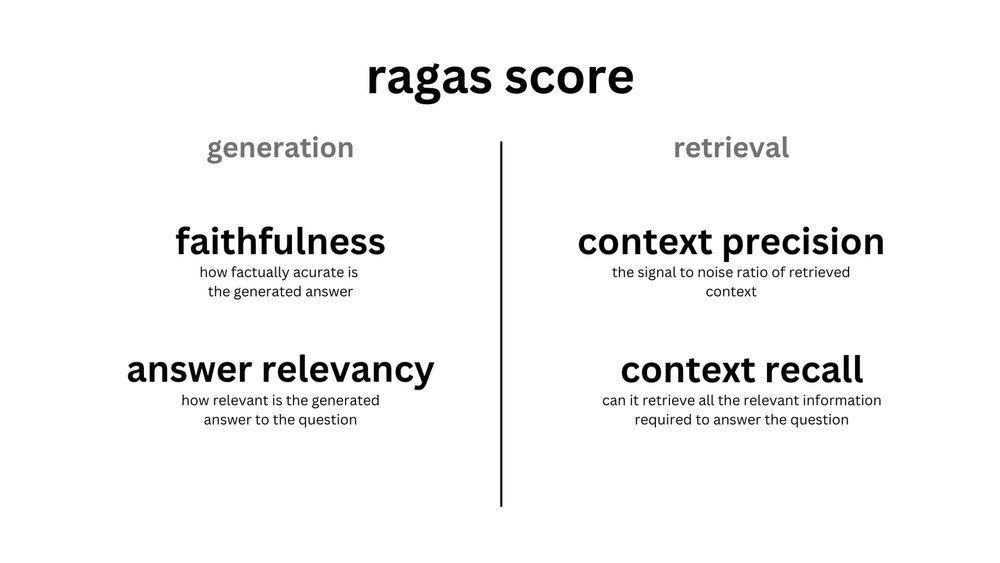


In [11]:
from tqdm import tqdm

# Sample size and seed come from the shared config, not from this cell: whatever
# lab_sample_size says there is what every lab runs, so Lab 2 and Lab 3 are measuring
# the same questions. It is set large enough to see the pattern and small enough to
# finish inside the time box. The seed is fixed so that your numbers and your
# neighbour's are comparable.
N_QUESTIONS = SHARED['lab_sample_size']
sample_test_df = golden_df.sample(N_QUESTIONS, random_state=SHARED['random_state']).reset_index(drop=True)
print(f"answering {N_QUESTIONS} golden questions with {MODEL}")

output = []

def process_question(row):
    """Processes a single question and returns the required output format."""
    temp_info = {'question': row['input']}
    temp_info['ground_truth'] = row['expected_output']
    nodes = retriever.retrieve(row['input'])
    context_str = "\n\n".join([n.node.get_content() for n in nodes])
    messages_chat = [
                {"content": qa_template.format(context_str=context_str, query_str=row['input']), "role": "user"}
            ]

    # MODEL is the LiteLLM form from the shared config. Lab 2 uses the cheaper model on
    # purpose: it fires more calls per attendee than any other lab.
    response = completion(model=MODEL, messages=messages_chat, temperature=1, stream=False)
    response_text = response.choices[0].message.content
    temp_info['answer'] = response_text # Convert response object to string
    temp_info['contexts'] = [node.node.text for node in nodes]
    return temp_info


for _, row in tqdm(sample_test_df.iterrows(), total=sample_test_df.shape[0]):
    output.append(process_question(row))


sample_test_df = pd.DataFrame(output)

answering 15 golden questions with openrouter/openai/gpt-4.1-nano


100%|██████████| 15/15 [00:46<00:00,  3.07s/it]

time: 46.1 s (started: 2026-09-21 21:27:24 +00:00)


In [12]:
sample_test_df.sample(5)

,question,ground_truth,answer,contexts
3,What are the steps to register for and access ...,Visit eap.calhr.ca.gov and search for the Disc...,To register for and access the LifeMart Discou...,[Employee Assistance Program\nYour resource fo...
8,How do I submit DCRA claims using the ASIFlex ...,"Download the ASIFlex mobile app, log in to you...",To submit DCRA (Dependent Care Reimbursement A...,[Does a DCRA impact the tax credit on my incom...
11,What confidential guidance does the Employee A...,The EAP provides confidential consultations an...,The Employee Assistance Program (EAP) provides...,[Employee Assistance Program\nYour resource fo...
4,What are the 2027 monthly premiums for family ...,The 2027 monthly premium for family coverage u...,The 2027 monthly premiums for family coverage ...,[2027 Dental Premium Comparison\nThe Delta Den...
2,Can surviving dependents continue dental cover...,Surviving dependents can continue their curren...,"Yes, surviving dependents can continue their d...",[Survivor Benefits \nDepartments are required ...


time: 220 ms (started: 2026-09-21 21:29:21 +00:00)


In [13]:
sample_test_df.head(1)

,question,ground_truth,answer,contexts
0,Is Accident and Critical Illness coverage avai...,"Yes, for 2026, you can elect Accident and Crit...","Yes, in the 2026 plan, Accident Insurance (AI)...",[2027 Benefits Summary for Active State Employ...


time: 12.8 ms (started: 2026-09-21 21:29:24 +00:00)


In [14]:
# RAGAS needs to be told where to send BOTH its judge calls and its embedding calls.
# Passing only the judge leaves answer_relevancy on OpenAI's defaults, where it dies
# without an OpenAI key. Point both at OpenRouter.
_openrouter = dict(base_url="https://openrouter.ai/api/v1",
                   api_key=os.environ["OPENROUTER_API_KEY"])

# The judge model comes from the shared config, so every table in the room is scored by the
# same judge. The embedding line below keeps OpenRouter's unprefixed spelling: this path is
# LangChain with base_url set, not LiteLLM, so the 'openrouter/' prefix used elsewhere in
# this notebook would not resolve here.
ragas_judge = LangchainLLMWrapper(
    ChatOpenAI(model=SHARED['judge_model'], temperature=0, **_openrouter))
ragas_embeddings = LangchainEmbeddingsWrapper(
    OpenAIEmbeddings(model="openai/text-embedding-3-small", **_openrouter))

result = evaluate(
    Dataset.from_pandas(sample_test_df[['question', 'ground_truth', 'answer', 'contexts']]),
    metrics=[
        context_precision,
        faithfulness,
        answer_relevancy,
        context_recall,
    ],
    llm=ragas_judge,
    embeddings=ragas_embeddings,
)

# A judge call that hits a rate limit does not raise here, it comes back with no score, and
# the average is then quietly taken over whatever survived. Count them, so an average over
# four answers is never mistaken for an average over ten.
scores_df = result.to_pandas()
metric_cols = [c for c in scores_df.columns
               if c in ("context_precision", "faithfulness", "answer_relevancy", "context_recall")]
unscored = scores_df[metric_cols].isna().sum()
if unscored.any():
    print("Some judge calls came back without a score:")
    for metric, n in unscored[unscored > 0].items():
        print(f"  {metric}: {n} of {len(scores_df)} unscored, "
              f"so that average is over {len(scores_df) - n} questions.")
    print("Rerun the cell if you want a clean set. The scores below are still readable.")
else:
    print(f"Every metric scored all {len(scores_df)} questions.")

result

/tmp/ipykernel_4576/164846445.py:11: DeprecationWarning: LangchainLLMWrapper is deprecated and will be removed in a future version. Use llm_factory instead: from openai import OpenAI; from ragas.llms import llm_factory; llm = llm_factory('gpt-4o-mini', client=OpenAI(api_key='...'))
  ragas_judge = LangchainLLMWrapper(
/tmp/ipykernel_4576/164846445.py:13: DeprecationWarning: LangchainEmbeddingsWrapper is deprecated and will be removed in a future version. Use the modern embedding providers instead: embedding_factory('openai', model='text-embedding-3-small', client=openai_client) or from ragas.embeddings import OpenAIEmbeddings, GoogleEmbeddings, HuggingFaceEmbeddings
  ragas_embeddings = LangchainEmbeddingsWrapper(


Evaluating:   0%|          | 0/60 [00:00<?, ?it/s]

Every metric scored all 15 questions.


{'context_precision': 0.7047, 'faithfulness': 0.8941, 'answer_relevancy': 0.8423, 'context_recall': 0.8333}

time: 1min 19s (started: 2026-09-21 21:29:26 +00:00)


Given the small subset of testing examples, we can start to measure how well our system is doing. That being said, there are many ways for us to further evaluate the system as well as explore how to improve. We will explore this more during the next lab.

A baseline exists for this corpus, measured over five full runs of exactly this notebook:

```
context_precision  0.79      faithfulness   0.94
answer_relevancy   0.78      context_recall 0.89
```

**Expect to land within about ±0.03 of each.** Generation runs at `temperature=1`, so your numbers will not match to four decimal places and they are not supposed to. Across five runs no metric moved more than 0.045, so a result inside that band is the system working, not a bug.

You should see roughly **357 chunks** indexed from 186 pages. Lab 3 downloads a corpus of 255 chunks over the same documents. Both are correct: this notebook chunks the PDFs itself, and Lab 3 uses a corpus parsed separately with LlamaParse. Different parse, different chunk boundaries, same source material.

You will also see `LLM returned 1 generations instead of requested 3` repeated during scoring. `answer_relevancy` asks the judge to reverse-engineer three questions from each answer and OpenRouter returns one, so that metric scores on a single sample. It is harmless, it is the same for everyone, and it is why `answer_relevancy` is the noisiest of the four.

### These are good scores, and that is the interesting part

For comparison, the same four metrics over the BEHR paint corpus:

```
{'context_precision': 0.6867, 'faithfulness': 0.7028, 'answer_relevancy': 0.3917, 'context_recall': 0.7307}

```

Benefits documents beat paint data sheets on every metric, and on `answer_relevancy` it is not close. That makes sense: handbooks are written in prose for people who need to act on them, while a technical data sheet is a dense table of coverage rates and cure times that a retriever can find and a generator still struggles to answer from.

It also sets up Lab 3 honestly. With faithfulness at 0.94 and recall at 0.89 there is very little headroom left, so do not expect the improved retriever to move these aggregates much. It does not. What Lab 3 is actually for is finding *where* this system still fails, and a corpus that scores well on average can still fail badly on the questions that matter. Two are already waiting in this corpus.

time: 2min 8s (started: 2026-09-21 21:29:26 +00:00)
